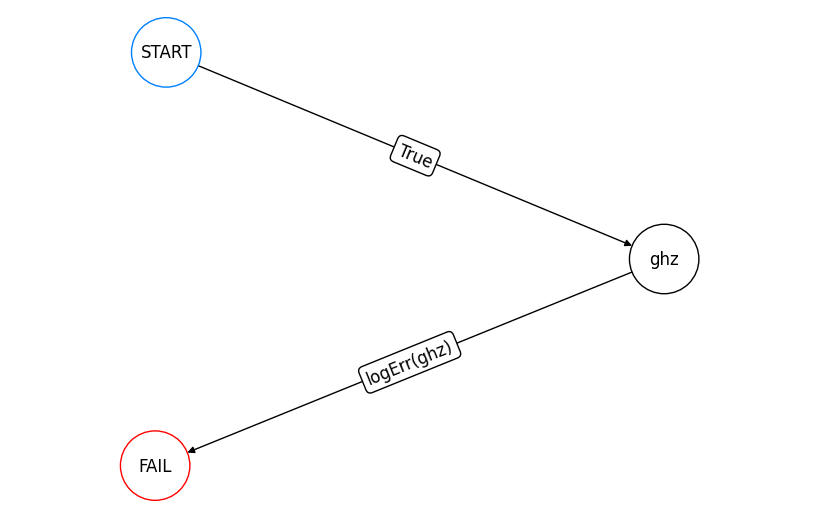

In [2]:
import qsample as qs
import time
import matplotlib.pyplot as plt

ghz = qs.Circuit([ {"init": {0,1,2,3,4}},
                   {"H": {0}},
                   {"CNOT": {(0,1)}},
                   {"CNOT": {(1,2)}},
                   {"CNOT": {(2,3)}},
                   {"CNOT": {(3,4)}},
                   {"CNOT": {(0,4)}},
                   {"measure": {4}}   ])

# Define protocol for 1 round of repetition

def logErr(msmt_list):
    return msmt_list[-1] == 1 # If True transition to FAIL

functions = {'logErr': logErr}

ghz1 = qs.Protocol(check_functions=functions, fault_tolerant=False)

ghz1.add_node('ghz', circuit=ghz) # Add node with corresponding circuit
ghz1.add_edge('START', 'ghz', check='True') # Transition START -> first circuit node always True
ghz1.add_edge('ghz', 'FAIL', check='logErr(ghz)')

ghz1.draw(figsize=(8,5), path = 'protocol_ghz')

p=('1.00e-02',): 100%|██████████| 1000/1000 [00:00<00:00, 6881.59it/s]
/var/folders/dd/4yhpjrt92t3fr6_cq5glj9b80000gn/T/ipykernel_42230/498514354.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


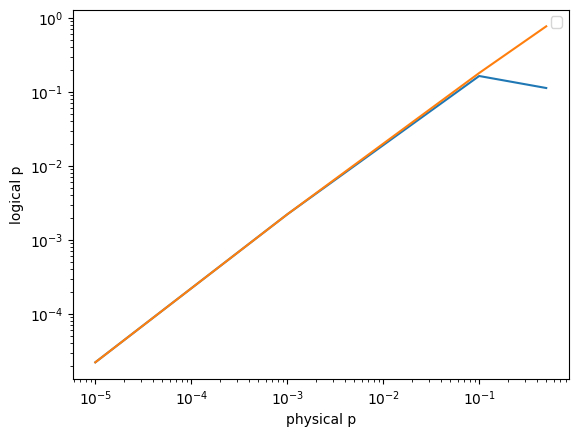

In [3]:
err_model = qs.noise.E1
q = [1e-5, 1e-3, 1e-1, 0.5]
err_params = {'q': q}

ss_sam = qs.SubsetSampler(protocol=ghz1, simulator=qs.StimSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
ss_sam.run(1000)

stats = ss_sam.stats()
plt.plot(q, stats[0])
plt.plot(q, stats[2])


plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('physical p')
plt.ylabel('logical p')

plt.savefig('plog_ghz')

p=('1.00e-02',): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 11392.17it/s]


Text(0.5, 0, '# of samples')

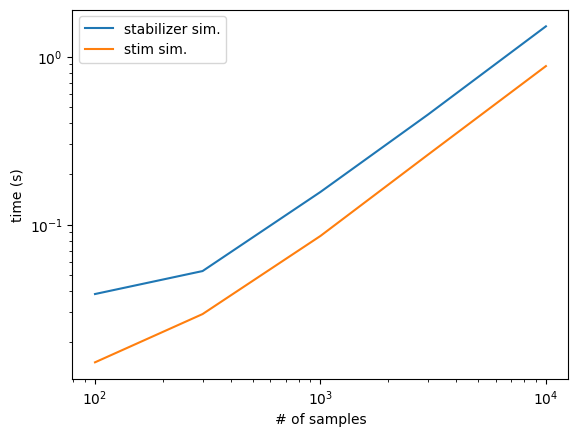

In [7]:
err_model = qs.noise.E1
q = [1e-5, 1e-3, 1e-1, 0.5]
err_params = {'q': q}


qsample_times = []
stim_times = []

samples = [100, 300, 1000, 3000, 10000]

for s in samples:
    begin = time.time()
    ss_sam = qs.SubsetSampler(protocol=ghz1, simulator=qs.StabilizerSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
    ss_sam.run(s)
    end = time.time()
    qsample_times.append(end-begin)

    begin = time.time()
    ss_sam = qs.SubsetSampler(protocol=ghz1, simulator=qs.StimSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
    ss_sam.run(s)
    end = time.time()
    stim_times.append(end-begin)

plt.plot(samples, qsample_times, label = 'stabilizer sim.')
plt.plot(samples, stim_times, label = 'stim sim.')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.ylabel('time (s)')
plt.xlabel('# of samples')

#print('Average ratio of stim time/stabilizer time: {:.2f}'.format(np.average(np.array(stim_times)/np.array(qsample_times))))